In [562]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math

In [563]:
df = pd.read_csv("papers.csv")
total_papers = len(df)
df.columns


Index(['Title', 'Database ', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Data Details', 'Size', 'Number of Prompts',
       'Topic', 'Notes', 'Racial Bias', 'Language Bias', 'Age Bias',
       'Gender Bias', 'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Evaluated LLMs', 'Reference Standard', 'Patient Inclusion',
       'Has Debiasing', 'Debias Focus', 'Debias Details'],
      dtype='str')

In [564]:
language_groups_lst = df["Language Bias"].tolist()


In [565]:
language_groups_freqs = defaultdict(int)

for s in language_groups_lst:
    
    if isinstance(s, float):
        language_groups_freqs[str(s)] += 1
        continue
    
    s = s.strip().lower()
    s = s.replace("_", " ")
    
    if s == "no":
        language_groups_freqs[s] += 1
        continue
    
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue   # skip malformed rows safely
    
    items = match.group(1)   # <-- only inside parentheses
    languages = [lang.strip() for lang in items.split(',')]
    
    for language in languages:
        language_groups_freqs[language] += 1

        

In [566]:
del language_groups_freqs["no"]

language_groups_freqs["english"] += language_groups_freqs["aave"]
del language_groups_freqs["aave"]

language_groups_freqs["arabic"] += 1
del language_groups_freqs["saudi arabic"]
del language_groups_freqs["egyptian arabic"]
del language_groups_freqs["lebanese arabic"]
del language_groups_freqs["moroccan arabic"]


language_groups_freqs = dict(
    sorted(
        language_groups_freqs.items(), 
        key=lambda item: item[1],
        reverse=True
    )[:10]
)

print(language_groups_freqs)

{'english': 14, 'spanish': 5, 'arabic': 4, 'chinese': 3, 'japanese': 2, 'polish': 1, 'dutch': 1, 'kazakh': 1, 'russian': 1, 'brazilian portuguese': 1}


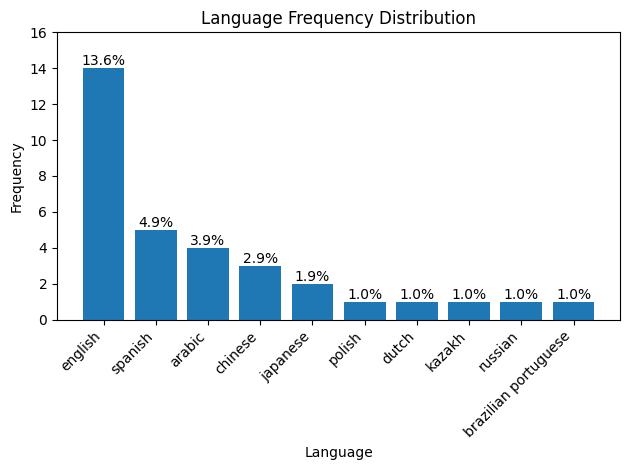

In [567]:
plt.figure()

languages = list(language_groups_freqs.keys())
counts = list(language_groups_freqs.values())

bars = plt.bar(languages, counts)

for i, count in enumerate(counts):
    percent = (count / total_papers) * 100
    plt.text(i, count, f"{percent:.1f}%",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Language")
plt.ylabel("Frequency")
plt.ylim((0, 16))
plt.title("Language Frequency Distribution")
plt.tight_layout()
plt.show()

In [568]:
racial_groups_lst = df["Racial Bias"].tolist()

racial_groups_freqs = defaultdict(int)

for s in racial_groups_lst:
    
    if isinstance(s, float):
        racial_groups_freqs[str(s)] += 1
        continue
    
    s = s.strip().lower()
    s = s.replace("_", " ")
    
    if s == "no":
        racial_groups_freqs[s] += 1
        continue
    
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue
    
    items = match.group(1) 
    races = [race.strip() for race in items.split(',')]
    
    for race in races:
        racial_groups_freqs[race] += 1

In [569]:
racial_groups_freqs

del racial_groups_freqs["no"]
del racial_groups_freqs["e.g."]
del racial_groups_freqs["non-soc"]
del racial_groups_freqs["soc"]
del racial_groups_freqs["undetermined"]
del racial_groups_freqs["racial groups based on cohort metadata"]
del racial_groups_freqs["non-white"]
del racial_groups_freqs["race categories reported in the study"]

# asian
racial_groups_freqs["asian"] += racial_groups_freqs["east asian"]
racial_groups_freqs["asian"] += racial_groups_freqs["and east asian"]
racial_groups_freqs["asian"] += racial_groups_freqs["south asian"]
racial_groups_freqs["asian"] += racial_groups_freqs["asian american"]
del racial_groups_freqs["and east asian"]
del racial_groups_freqs["east asian"]
del racial_groups_freqs["south asian"]
del racial_groups_freqs["asian american"]

# african american
racial_groups_freqs["black"] += racial_groups_freqs["black or african american"]
racial_groups_freqs["black"] += racial_groups_freqs["african american"]
racial_groups_freqs["black"] += racial_groups_freqs["black vs others"]
racial_groups_freqs["black"] += racial_groups_freqs["non hispanic black"]
del racial_groups_freqs["black or african american"]
del racial_groups_freqs["african american"]
del racial_groups_freqs["black vs others"]
del racial_groups_freqs["non hispanic black"]

# native american
racial_groups_freqs["native american"] += racial_groups_freqs["american indian/native american"]
racial_groups_freqs["native american"] += racial_groups_freqs["american indian"]
racial_groups_freqs["native american"] += racial_groups_freqs["american indian or alaska native"]
del racial_groups_freqs["american indian/native american"]
del racial_groups_freqs["american indian"]
del racial_groups_freqs["american indian or alaska native"]

# hispanic
racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino"]
racial_groups_freqs["hispanic"] += racial_groups_freqs["latinx"]
racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino americans"]
racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino or of spanish origin"]
racial_groups_freqs["hispanic"] += racial_groups_freqs["latino"]
del racial_groups_freqs["hispanic or latino"]
del racial_groups_freqs["latinx"]
del racial_groups_freqs["hispanic or latino americans"]
del racial_groups_freqs["hispanic or latino or of spanish origin"]
del racial_groups_freqs["latino"]

# pacifical islander
racial_groups_freqs["pacific islander"] += racial_groups_freqs["native hawaiian or other pacific islander"]
racial_groups_freqs["pacific islander"] += racial_groups_freqs["native hawaiian"]
del racial_groups_freqs["native hawaiian or other pacific islander"]
del racial_groups_freqs["native hawaiian"]

# white
racial_groups_freqs["white"] += racial_groups_freqs["caucasian"]
racial_groups_freqs["white"] += racial_groups_freqs["european american"]
racial_groups_freqs["white"] += racial_groups_freqs["non hispanic white"]
del racial_groups_freqs["caucasian"]
del racial_groups_freqs["european american"]
del racial_groups_freqs["non hispanic white"]

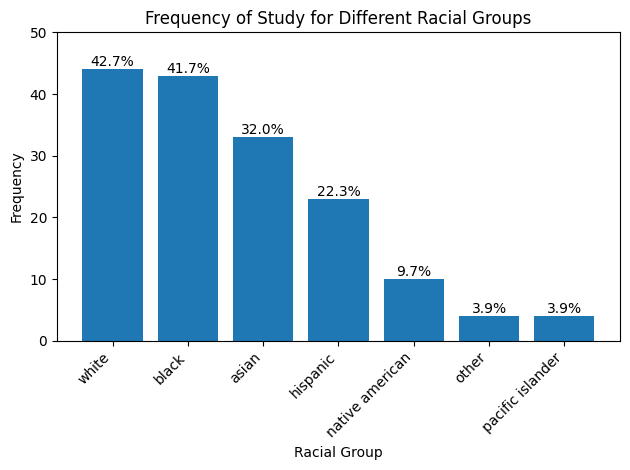

In [570]:
racial_groups_freqs = dict(
    sorted(
        racial_groups_freqs.items(), 
        key=lambda item: item[1],
        reverse=True
    )[:7]
)

plt.figure()

races = list(racial_groups_freqs.keys())
counts = list(racial_groups_freqs.values())

bars = plt.bar(races, counts)

for i, count in enumerate(counts):
    percent = (count / total_papers) * 100
    plt.text(i, count, f"{percent:.1f}%",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Racial Group")
plt.ylabel("Frequency")
plt.ylim((0, 50))
plt.title("Frequency of Study for Different Racial Groups")
plt.tight_layout()
plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_83804/3377006272.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(m + " 1 " + y.astype("Int64").astype(str), errors="coerce")


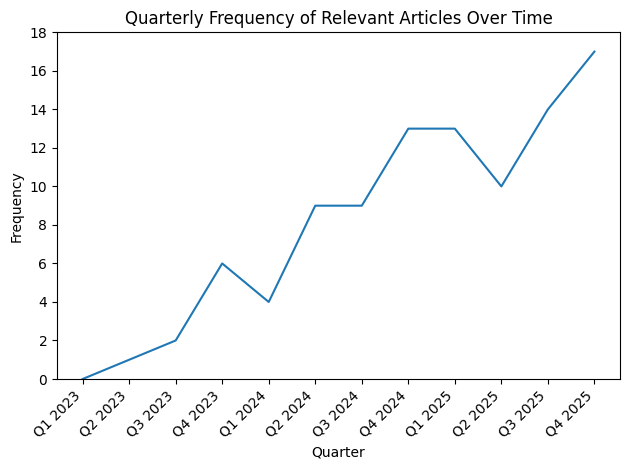

In [571]:
m = (df["Month"]
     .astype(str)
     .str.strip()
     .str.lower()
     .replace({"jun": "june", "jul": "july", "aug": "august",
               "sep": "september", "oct": "october", "dec": "december"})
)

m = m.mask(m.isin(["nan", "unsure", "unclear"]))
y = pd.to_numeric(df["Year"], errors="coerce")
df["date"] = pd.to_datetime(m + " 1 " + y.astype("Int64").astype(str), errors="coerce")
df = df.dropna(subset=["date"])

counts = (
    df.groupby(df["date"].dt.to_period("Q"))
      .size()
      .sort_index()
)

full_range = pd.period_range(
    start="2023Q1",   # force inclusion
    end=counts.index.max(),
    freq="Q"
)

counts = counts.reindex(full_range, fill_value=0)

counts.index = [f"Q{p.quarter} {p.year}" for p in counts.index]

plt.figure()
plt.plot(counts.index, counts.values)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Quarter")
plt.ylabel("Frequency")
plt.yticks(np.arange(0, max(counts.values) + 2, 2))
plt.title("Quarterly Frequency of Relevant Articles Over Time")
plt.ylim((0, 18))
plt.tight_layout()
plt.show()

In [572]:
llms_lst = df["Evaluated LLMs"].dropna().tolist()

freq_mp = Counter(
    model.strip()
    for entry in llms_lst
    for model in entry.split(",")
)

freq_mp

Counter({'ChatGPT-4': 12,
         'ChatGPT': 8,
         'ChatGPT-3.5': 7,
         'GPT-4': 6,
         'ChatGPT-4.0': 4,
         'GPT-4o-mini': 4,
         'BioMistral-7B': 4,
         'GPT-4o': 3,
         'Gemini': 3,
         'Bard': 3,
         'ChatGPT-4o': 3,
         'GPT-3.5': 3,
         'Aug 3)': 3,
         'Gemma-2-9B-it': 2,
         'Gemini 1.5 Flash': 2,
         'MentaLLaMA': 2,
         'BERT': 2,
         'ChatGPT-3.5-turbo': 2,
         'GPT-4 Turbo': 2,
         'GPT-3.5 Turbo': 2,
         'ChatGPT 3.5': 2,
         'ChatGPT 4.0': 2,
         'Llama3-Med42-8B': 1,
         'Microsoft’s Bing A.I. Image Creator': 1,
         'Phi-3.5-mini-instruct': 1,
         'Phi-3-medium-128k-instruct': 1,
         'Llama-3.1-8B': 1,
         'Llama-3.1-70B': 1,
         'Gemma-2-27B': 1,
         'Qwen2-7B': 1,
         'Qwen2-72B': 1,
         'Claude 3 Haiku': 1,
         'Stanford Medicine Secure GPT': 1,
         'Med-PaLM2': 1,
         'Med-PaLM': 1,
         'ERNIE': 

In [573]:
# ChatGPT
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.0']
freq_mp["ChatGPT"] += freq_mp['GPT-4o-mini']
freq_mp["ChatGPT"] += freq_mp['GPT-4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4o']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-4 Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5 Turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4.0']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s GPT-4']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['COT-ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4-o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3']
freq_mp["ChatGPT"] += freq_mp['GPT‑2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT (3.5 versions May 12']
freq_mp["ChatGPT"] += freq_mp['GPT‑4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']

del freq_mp['ChatGPT-4']
del freq_mp['ChatGPT-3.5']
del freq_mp['GPT-4']
del freq_mp['ChatGPT-4.0']
del freq_mp['GPT-4o-mini']
del freq_mp['GPT-4o']
del freq_mp['ChatGPT-4o']
del freq_mp['GPT-3.5']
del freq_mp['ChatGPT-3.5-turbo']
del freq_mp['GPT-4 Turbo']
del freq_mp['GPT-3.5 Turbo']
del freq_mp['ChatGPT 3.5']
del freq_mp['ChatGPT 4.0']
del freq_mp['OpenAI’s GPT-4']
del freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
del freq_mp['GPT-3.5-Turbo']
del freq_mp['COT-ChatGPT-4']
del freq_mp['ChatGPT-4.5']
del freq_mp['GPT-3.5-turbo']
del freq_mp['GPT3.5-turbo']
del freq_mp['ChatGPT-2']
del freq_mp['ChatGPT4']
del freq_mp['ChatGPT3.5']
del freq_mp['GPT-4-o']
del freq_mp['ChatGPT-3']
del freq_mp['GPT‑2']
del freq_mp['ChatGPT (3.5 versions May 12']
del freq_mp['GPT‑4']
del freq_mp['ChatGPT 4o']

# Gemini
freq_mp["Gemini"] += freq_mp['Gemini 1.5 Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.5-Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.0-pro']
freq_mp["Gemini"] += freq_mp['Gemini-3.5-Flash)']

del freq_mp['Gemini 1.5 Flash']
del freq_mp['Gemini-1.5-Flash']
del freq_mp['Gemini-1.0-pro']
del freq_mp['Gemini-3.5-Flash)']


# Llama
freq_mp["Llama"] += freq_mp["Llama-2 (13b)"]
freq_mp["Llama"] += freq_mp["Llama-2 (7b)"]
freq_mp["Llama"] += freq_mp['Llama-3.1-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-70B']
freq_mp["Llama"] += freq_mp['Llama3-70b']
freq_mp["Llama"] += freq_mp['LLama3-70B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['LLaMA-2']
freq_mp["Llama"] += freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
freq_mp["Llama"] += freq_mp['Llama-3-70b']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-70B']
freq_mp["Llama"] += freq_mp['Llama-3.2-3B Instruct']
freq_mp["Llama"] += freq_mp['Llama3-Med42-8B']
freq_mp["Llama"] += 16


del freq_mp["Llama-2 (13b)"]
del freq_mp["Llama-2 (7b)"]
del freq_mp['Llama-3.1-8B']
del freq_mp['Llama-3.1-70B']
del freq_mp['Llama3-70b']
del freq_mp['LLama3-70B']
del freq_mp['Llama3.1-403B']
del freq_mp['Llama3.1-403B']
del freq_mp['LLaMA-2']
del freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
del freq_mp['Llama-3-70b']
del freq_mp['Llama-3.1-Instruct-8B']
del freq_mp['Llama-3.1-Instruct-70B']
del freq_mp['Llama-3.2-3B Instruct']
del freq_mp['Llama3-Med42-8B']

# Claude  
freq_mp["Claude"] += freq_mp["COT-Claude-3"]
freq_mp["Claude"] += freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
freq_mp["Claude"] += freq_mp["Claude 3 Haiku"]
freq_mp["Claude"] += freq_mp["Haiku"]
freq_mp["Claude"] += 8

del freq_mp["COT-Claude-3"]
del freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
del freq_mp["Claude 3 Haiku"]
del freq_mp["Haiku"]

# Qwen
freq_mp["Qwen"] += freq_mp['Qwen2-7B']
freq_mp["Qwen"] += freq_mp['Qwen2-72B']
freq_mp["Qwen"] += freq_mp['Qwen-turbo']
freq_mp["Qwen"] += freq_mp['Qwen1.5-72b']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-SFT']
freq_mp["Qwen"] += freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']

del freq_mp['Qwen2-7B']
del freq_mp['Qwen2-72B']
del freq_mp['Qwen-turbo']
del freq_mp['Qwen1.5-72b']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-7B-Chat']
del freq_mp['Qwen1.5-7B-SFT']
del freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']

freq_mp["Mistral"] = 8

freq_mp["Gemma"] = 8

freq_mp["Yi"] = 4

freq_mp["Microsoft"] = 8

freq_mp["Qwen"] = 10

freq_mp["Baichuan"] = 2

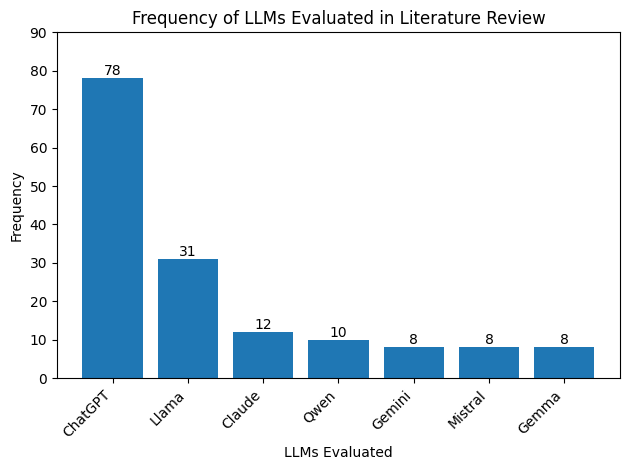

In [574]:
llms_freqs = dict(
    sorted(
        freq_mp.items(), 
        key=lambda item: item[1],
        reverse=True
    )[:7]
)

plt.figure()

llms = list(llms_freqs.keys())
counts = list(llms_freqs.values())

bars = plt.bar(llms, counts)

# Show counts only
for i, count in enumerate(counts):
    plt.text(i, count, str(count),
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("LLMs Evaluated")
plt.ylabel("Frequency")
plt.ylim((0, 90))
plt.title("Frequency of LLMs Evaluated in Literature Review")
plt.tight_layout()
plt.show()